#### load test wav

In [37]:
import librosa
import numpy as np

from scipy import interpolate
from scipy.signal import decimate, resample
from scipy.signal import butter, cheby1, bessel, lfilter

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors

In [38]:
High, fs = librosa.load(r'.\default_log_name.lr0.000500.1.g4.b100\eval\p225_366.wav.speaker-out.hr.wav', sr=16000)
Super, fs = librosa.load(r'.\default_log_name.lr0.000500.1.g4.b100\eval\p225_366.wav.speaker-out.pr.wav', sr=16000)

In [39]:
def load_h5(h5_path):
    # load training data
    with h5py.File(h5_path, 'r') as hf:
        print('List of arrays in input file:', list(hf.keys()))
        X = np.array(hf.get('data'))
        Y = np.array(hf.get('label'))
        print('Shape of X:', X.shape)
        print('Shape of Y:', Y.shape)

    return X, Y

def Filter(data, cutoff, fs, order=8, filter_type='Cheby1'):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    if filter_type == 'Butter':
        b, a = butter(order, normal_cutoff)
    elif filter_type == 'Bessel':
        b, a = bessel(order, normal_cutoff)
    else:
        b, a = cheby1(order, 1, normal_cutoff)
    return lfilter(b, a, data)

def upsample(x_lr, r):
    x_lr = x_lr.flatten()
    x_hr_len = len(x_lr) * r
    x_sp = np.zeros(x_hr_len)

    i_lr = np.arange(x_hr_len, step=r, dtype = "float32")
    i_hr = np.arange(x_hr_len, dtype = "float32")

    f = interpolate.splrep(i_lr, x_lr)

    x_sp = interpolate.splev(i_hr, f)

    return x_sp

def spline_up(x_lr, r):
    x_lr = x_lr.flatten()
    x_hr_len = len(x_lr) * r
    x_sp = np.zeros(x_hr_len)

    i_lr = np.arange(x_hr_len, step=r)
    i_hr = np.arange(x_hr_len)

    f = interpolate.splrep(i_lr, x_lr)

    x_sp = interpolate.splev(i_hr, f)

    return x_sp

In [40]:
Low = decimate(High, 2)
Low = spline_up(Low, 2)
Low = Filter(Low, np.floor(16000 / (2 * 2)), 16000, filter_type='Cheby1')

# downscale signal
Cubic = Filter(High, np.floor(16000 / (2 * 2)), 16000, filter_type='Cheby1')
Cubic = decimate(Cubic, 2)
Cubic = spline_up(Cubic, 2)

In [41]:
print(len(High),len(Low),len(Cubic),len(Super))

86016 86016 86016 86016


In [42]:
def draw_spec(*param, name=None, save=None, a=6, b=5, show=True, bar=False):
    # ------------------dft parameters---------------------
    FFT=16000
    HOP=160
    WIN=512
    FS=16000
    DT=2
    # ------------------ for color--------------------------
    COLOR="coolwarm"
    # ---------------- loop to draw ------------------------
    n = len(param)
    if n > 1:
        fig, axs = plt.subplots(1, n, sharey=True, figsize=(a, b))
        images = []
        for col, signal in enumerate(param):
            ax = axs[col]

            S_signal = librosa.stft(signal, n_fft=FFT, hop_length=HOP, win_length=WIN)  # D x T
            Mag_signal = np.abs(S_signal)
            Mag_signal_db = librosa.amplitude_to_db(Mag_signal)

            Y = np.arange(0,np.shape(Mag_signal_db)[0],1)
            X = np.arange(0,np.shape(Mag_signal_db)[1]/FS,1/FS)

            pcm = ax.pcolormesh(X, Y, Mag_signal_db, shading='auto', cmap="coolwarm")

            ax.set_xlim([0,np.shape(Mag_signal_db)[1]/FS])
            images.append(pcm)
            ax.label_outer()
            ax.set_ylim([1, int(FFT / 2 + 1)])
            ax.set_xlabel('Time (s)')
            ax.grid(False)
            if name:
                ax.set_title("{}".format(name[col]))
            if col == 0:
                ax.set_ylabel('Frequency (Hz)')

        # Find the min and max of all colors for use in setting the color scale.
        if bar:
            vmin = min(image.get_array().min() for image in images)
            vmax = max(image.get_array().max() for image in images)
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
            for im in images:
                im.set_norm(norm)
            fig.colorbar(images[0], ax=axs, orientation='horizental', fraction=.05, label='Magnitude(dB)')

    else:
        if np.ndim(param[0]) == 2:
            pcm = plt.imshow(param[0], cmap=COLOR)
        else:
            S_signal = librosa.stft(param[0], n_fft=FFT, hop_length=HOP, win_length=WIN)
            Mag_signal = np.abs(S_signal)

            pcm = plt.imshow(librosa.amplitude_to_db(Mag_signal, ref=np.max), cmap="coolwarm")
        if name:
            plt.title("{}".format(name[0]))
        plt.ylim([0, int(FFT / 2 + 1)])
        plt.xlabel('Time (s)')
        plt.ylabel('Frequency (Hz)')
        plt.grid(False)
        plt.colorbar(pcm, label='Magnitude(dB)')
    if save:
        plt.savefig('{}.png'.format(save), dpi=600, bbox_inches="tight")
    if show:
        plt.show()

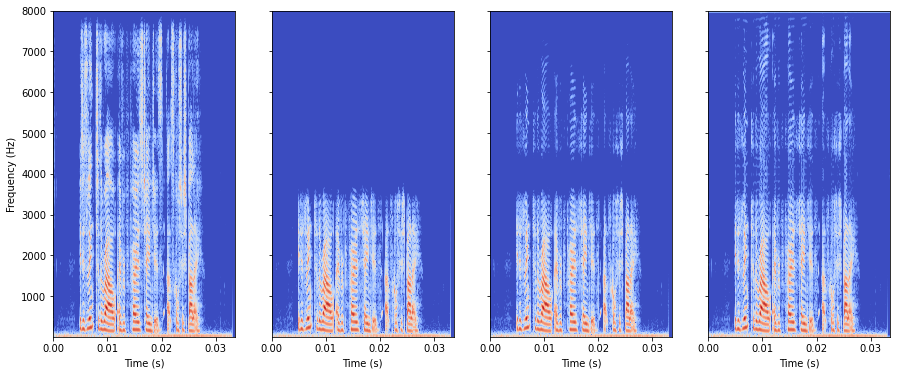

In [43]:
draw_spec(High,Low,Cubic,Super, a=15, b=6)

#### for visualization
Adopted from [matplotlib.org/stable/gallery](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html#sphx-glr-gallery-images-contours-and-fields-image-annotated-heatmap-py)

In [44]:
vegetables = ["High"]
farmers = ["High", "Low", "Cubic", "Super"]

In [45]:
def heatmap(data, row_labels, col_labels, ax=None,
            cbar_kw={}, cbarlabel="", **kwargs):
    
    if not ax:
        ax = plt.gca()

    # Plot the heatmap
    im = ax.imshow(data, **kwargs)

    
    cbar=plt.colorbar(im,orientation='horizontal')
    # Create colorbar
    #cbar = ax.figure.colorbar(im, ax=ax， **cbar_kw)
    #cbar.ax.set
    cbar.ax.set_xlabel(cbarlabel, va="top")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(np.arange(data.shape[1]))
    ax.set_xticklabels(labels=col_labels)
    ax.set_yticks(np.arange(data.shape[0]))
    ax.set_yticklabels(labels=row_labels)
    
    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right",
             rotation_mode="anchor")

    # Turn spines off and create white grid.
    #ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}",
                     textcolors=("black", "white"),
                     threshold=None, **textkw):

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center",
              verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = matplotlib.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
            text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)

    return texts

In [46]:
def test(lsd, V, U, High, Low, Cubic, Super):
    harvest = np.array([[lsd(High, High), lsd(High, Low), lsd(High, Cubic), lsd(High, Super)]])
                    #[lsd(High, Low), lsd(Low, Low), lsd(Cubic, Low), lsd(Super, Low)],
                    #[lsd(High, Cubic), lsd(Low, Cubic), lsd(Cubic, Cubic), lsd(Super, Cubic)],
                    #[lsd(High, Super), lsd(Low, Super), lsd(Cubic, Super), lsd(Super, Super)]])
    fig, ax = plt.subplots()

    im, cbar = heatmap(harvest, vegetables, farmers, ax=ax,
                       cmap="YlGn", cbarlabel="{} [{}]".format(V, U))
    texts = annotate_heatmap(im, valfmt="{x:.1f}")

    fig.tight_layout()
    plt.show()

#### test SNR
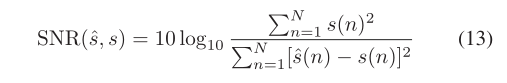

In [47]:
import pysepm
def snr(x,x_hat):
    if (x==x_hat).all():
        return 100#直接打满分，为了避免除数是0的情况
    else:
        return 10*np.log10(np.sum(x**2)/np.sum((x_hat-x)**2))

(86016,) (86016,)
(86016,) (86016,)
(86016,) (86016,)
(86016,) (86016,)


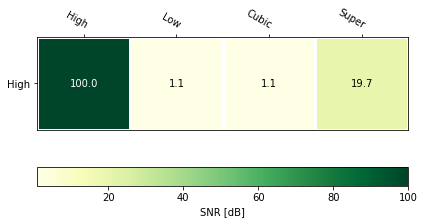

In [48]:
test(snr, 'SNR', 'dB', High, Low, Cubic, Super)

#### test LSD(log-spectral distance)
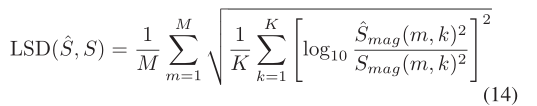

In [52]:
def get_log_spectral_distance(x, x_hat):

    # Compute FFT
    fft_1 = np.fft.fft(x)
    fft_2 = np.fft.fft(x_hat)

    # Compute power spectra
    power_spectrum_1 = np.abs(fft_1) ** 2
    power_spectrum_2 = np.abs(fft_2) ** 2

    # Compute LSD
    log_spectral_distance = np.sqrt(np.mean(np.power(np.log10(power_spectrum_1 / (power_spectrum_2+1e-8)), 2)))

    return log_spectral_distance

In [53]:
def lsd(x, x_hat):
    # The default set of librosa
    seg_length = 2048
    stride = -(-seg_length//4)
    
    n = len(x)
    X = [x[i:i + seg_length] for i in range(0, n - seg_length, stride)]
    Y = [x_hat[i:i + seg_length] for i in range(0, n - seg_length, stride)]
    lsd = []
    for a,b in zip(X,Y):
        lsd.append(get_log_spectral_distance(a,b))
    return np.mean(lsd)

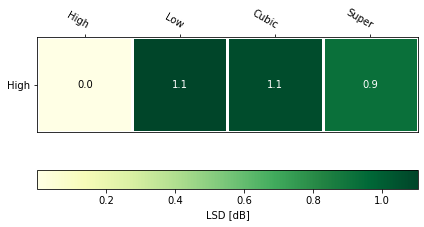

In [54]:
test(lsd, 'LSD', 'dB', High, Low, Cubic, Super)

#### test PESQ

In [16]:
import pysepm
def pesq(x,x_hat,fs=16000):
    return pysepm.pesq(x, x_hat, fs=fs)[-1]#clean_speech, noisy_speech,

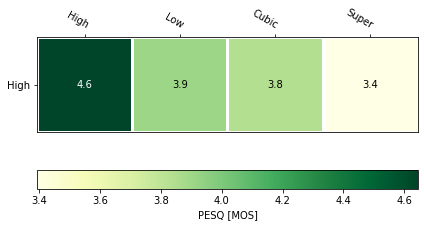

In [17]:
test(pesq, 'PESQ', 'MOS', High, Low, Cubic, Super)

In [18]:
def get_scores(High, Super):
    return snr(High, Super),lsd(High, Super), pesq(High, Super)

#### Loop files

In [19]:
import os
def find_wavs(input_path):
    # find all wav files
    flac_files = []
    for root, folders, files in os.walk(input_path):
        for file in filter(lambda x: x.endswith('wav'), files):
            if '._S_' in file:# for IEEE
                continue
            else:
                flac_files.append(os.path.join(root, file))
    return flac_files

In [55]:
path = r"D:\audiosr\src\default_log_name.lr0.000500.1.g4.b100\eval"
wavlist = find_wavs(path)
SNR=[]
LSD=[]
PESQ=[]
for low_path in wavlist:
    temp1 = low_path.find('eval')
    temp2 = low_path.find('.wav.')
    corpus_path = r"D:\audiosr\datasets\Corpus\VCTK\wav48\p225"
    high_path = os.path.join(corpus_path,wavlist[0][temp1+5:temp2+4])
    print(high_path)
    High, fs = librosa.load(high_path, sr=16000)
    Super, fs = librosa.load(low_path, sr=16000)
    MIN = min(len(High),len(Super))
    High = High[:MIN]
    Super = Super[:MIN]
    temp_snr, temp_lsd, temp_pesq = get_scores(High, Super)
    SNR.append(temp_snr)
    LSD.append(temp_lsd)
    PESQ.append(temp_pesq)
np.mean(SNR),np.mean(LSD),np.mean(PESQ)

D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (90112,)
(90063,) (90063,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (180224,)
(90063,) (90063,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (90112,)
(90063,) (90063,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (49152,)
(49152,) (49152,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (98304,)
(90063,) (90063,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (49152,)
(49152,) (49152,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (45056,)
(45056,) (45056,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (90112,)
(90063,) (90063,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (45056,)
(45056,) (45056,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (63488,)
(63488,) (63488,)
D:\audiosr\datasets\Corpus\VCTK\wav48\p225\p225_355.wav
(90063,) (126976,)
(900